In [ ]:
import pcxarray as pcx
import geopandas as gpd
from tqdm.notebook import tqdm, trange
from warnings import filterwarnings
from joblib import Parallel, delayed
from shapely import STRtree, Point
from rtree import index
import numpy as np
from rasterio.enums import Resampling
from sklearn.linear_model import LinearRegression
import os
from threading import Lock
import pandas as pd
import math
import matplotlib.pyplot as plt
from glob import glob
import shutil

filterwarnings('ignore')

max_num_samples = 250000 # maximum number of samples to extract
min_sample_dist = 2000 # minimum distance between samples
out_dir = os.path.join('..', 'data', 's2flow-s2naip')
target_resolution = 2.5 # in meters
tile_size = 256 # in pixels (tile_size x tile_size)

os.makedirs(out_dir, exist_ok=True)

In [4]:
conus_gdf = pcx.utils.load_census_shapefile(level='state')
conus_gdf = conus_gdf.loc[~conus_gdf['STUSPS'].isin(['AK', 'HI', 'PR', 'GU', 'VI', 'MP', 'AS'])]
# south_states = ["AL","AR","DE","DC","FL","GA","KY","LA","MD","MS","NC","OK","SC","TN","TX","VA","WV"]
# conus_gdf = conus_gdf.loc[conus_gdf['STUSPS'].isin(south_states)]
conus_geom = conus_gdf.dissolve().buffer(0.1).simplify(0.1).geometry.iloc[0]

In [ ]:
naip_observations_gdf = pd.concat([
    pcx.pc_query(
        collections='naip',
        geometry=conus_geom,
        crs=conus_gdf.crs,
        datetime=str(year),
    ) for year in trange(2010, 2025) # 2018-2024 (inclusive)
])
naip_observations_gdf.to_parquet(os.path.join(out_dir, 'naip_observations.par'))

In [3]:
def _query_row(geom, date_str, crs):
    try:
        res = pcx.pc_query(
            collections="sentinel-2-l2a",
            geometry=geom,
            crs=crs,
            datetime=date_str,
        )
        if res is None or len(res) == 0:
            return []
        else:
            return [geom.intersection(g) for g in res.geometry]
    except Exception:
        return []

inputs = []
for _, row in naip_observations_gdf.iterrows():
    dt = row['properties.datetime']
    if dt is None:
        continue
    inputs.append((row.geometry, dt.date().isoformat(), naip_observations_gdf.crs))

n_jobs = min(24, (len(inputs) or 1))  # tune for your machine / network
matching_regions = []
with tqdm(total=len(inputs)) as pbar:
    def _wrap(args):
        res = _query_row(*args)
        pbar.update()
        return res
    results = Parallel(n_jobs=n_jobs, prefer="threads", batch_size=1)(
        delayed(_wrap)(arg) for arg in inputs
    )

for r in results:
    matching_regions.extend(r)
candidate_regions_gdf = gpd.GeoDataFrame({'geometry': matching_regions}, crs=naip_observations_gdf.crs)

candidate_regions_gdf = gpd.GeoDataFrame({'geometry': matching_regions}, crs=naip_observations_gdf.crs)
candidate_regions_gdf = candidate_regions_gdf.dissolve().explode().reset_index()
candidate_regions_gdf = candidate_regions_gdf.to_crs(5070)
candidate_regions_gdf.to_parquet(os.path.join(out_dir, 'candidate_regions.par'))

NameError: name 'naip_observations_gdf' is not defined

In [ ]:
valid_regions_strtree = STRtree(candidate_regions_gdf.geometry)
invalid_regions_rtree = index.Index() 
pixel_buffer = int(math.ceil((tile_size * target_resolution) / 2.0))

minx, miny, maxx, maxy = candidate_regions_gdf.total_bounds

n_points = max_num_samples
sampled_points = []
np.random.seed(1701)

with tqdm(desc='Sampling points', total=n_points) as pbar:
    while len(sampled_points) < n_points:
        
        sample_x = np.random.uniform(minx, maxx)
        sample_y = np.random.uniform(miny, maxy)
        sample_point = Point(sample_x, sample_y)
        
        is_valid_region = False
        for potential_intersection in valid_regions_strtree.query(sample_point):
            if candidate_regions_gdf.iloc[potential_intersection].geometry.contains(sample_point.buffer(pixel_buffer)):
                is_valid_region = True
                break
        
        if not is_valid_region:
            continue
        
        for potential_intersection in invalid_regions_rtree.intersection(sample_point.bounds):
            if sampled_points[potential_intersection].buffer(min_sample_dist).intersects(sample_point):
                is_valid_region = False
                break
            
        if not is_valid_region:
            continue
        
        invalid_regions_rtree.insert(len(sampled_points), sample_point.buffer(min_sample_dist).bounds)
        sampled_points.append(sample_point)
        pbar.update(1)

sampled_points_gdf = gpd.GeoDataFrame(geometry=sampled_points, crs=candidate_regions_gdf.crs)
n_digits = len(str(len(sampled_points_gdf) - 1))
sampled_points_gdf['id'] = sampled_points_gdf.index.map(lambda x: str(x).zfill(n_digits))
sampled_points_gdf['split'] = ['val' if (i + 1) % 20 == 0 else 'train' for i in range(len(sampled_points_gdf))]
sampled_points_gdf.to_parquet(os.path.join(out_dir, 'sampled_points.par'))


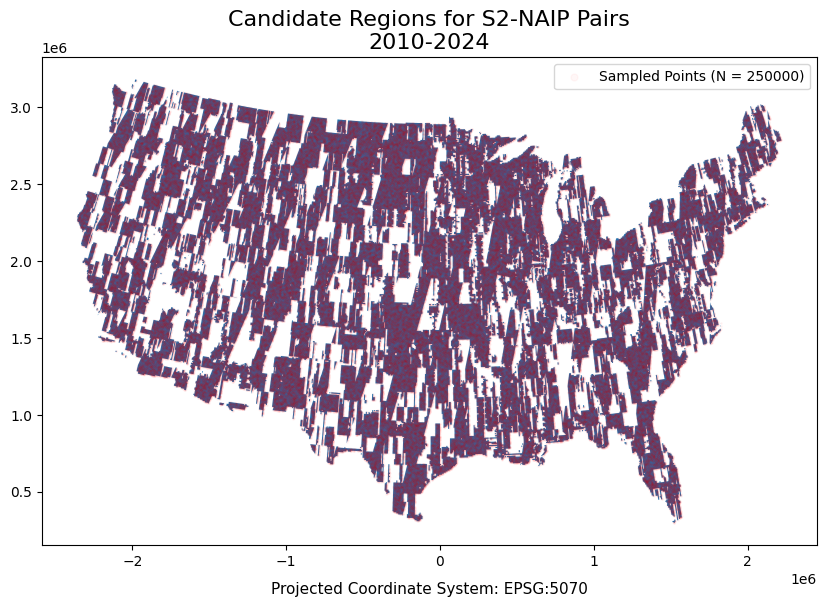

In [3]:
candidate_regions_gdf = gpd.read_parquet(os.path.join(out_dir, 'candidate_regions.par'))
sampled_points_gdf = gpd.read_parquet(os.path.join(out_dir, 'sampled_points.par'))

fig, ax = plt.subplots(figsize=(10, 8))
candidate_regions_gdf.plot(ax=ax, label='Candidate Regions')
ax.set_title('Candidate Regions for S2-NAIP Pairs\n2010-2024', fontsize=16)
ax.text(0.5, -0.1, f'Projected Coordinate System: EPSG:{candidate_regions_gdf.crs.to_epsg()}', transform=ax.transAxes, ha='center', fontsize=11)

sampled_points_gdf.plot(ax=ax, color='red', markersize=1, alpha=0.03, label=f'Sampled Points (N = {len(sampled_points_gdf)})')
ax.legend(markerscale=5)
# ax.axis('off')
plt.show()

In [ ]:
# valid_scl_values = [4, 5, 6, 11] 

# os.makedirs(os.path.join(out_dir, 'sentinel2'), exist_ok=True)
# os.makedirs(os.path.join(out_dir, 'naip'), exist_ok=True)

# with open(os.path.join(out_dir, 'datetime_info.csv'), 'w') as f:
#     f.write("id,naip_datetime_start,naip_datetime_end,s2_datetime_start,s2_datetime_end\n")
# dt_file_lock = Lock()

# np.random.seed(1701)

def process_sample(
    sample_row,
    crs,
    out_dir,
    valid_scl_values=(0, 4, 5, 6, 11), # nodata (will check again), vegetation, not-vegetated, water, snow
    target_resolution=target_resolution,
    resampling_method=Resampling.lanczos,
    tile_size=tile_size,
    write_opts=None,
) -> None:
    
    sid = None
    try:
        sid = sample_row.id
        naip_path = os.path.join(out_dir, 'naip', f"{sid}.tif")
        s2_path = os.path.join(out_dir, 'sentinel2', f"{sid}.tif")
        if os.path.exists(naip_path) and os.path.exists(s2_path):
            return
        
        # print(f"[process_sample] START sid={sid}")
        pixel_buffer = int(math.ceil((tile_size * target_resolution) / 2.0))
        geom = sample_row.geometry.buffer(pixel_buffer).envelope

        # print(f"[process_sample:{sid}] querying NAIP items for geometry (buffer={pixel_buffer})")
        naip_items_gdf = pcx.pc_query(
            collections='naip',
            geometry=geom,
            crs=crs,
        )
        if naip_items_gdf is None or len(naip_items_gdf) == 0:
            # print(f"[process_sample:{sid}] no NAIP items found, skipping")
            return 

        # print(f"[process_sample:{sid}] found {len(naip_items_gdf)} NAIP items")
        
        datetimes = naip_items_gdf['properties.datetime'].dt.year.unique()
        np.random.shuffle(datetimes)
        # print(f"[process_sample:{sid}] candidate years: {datetimes}")

        for naip_dt in datetimes:
            try:
                # print(f"[process_sample:{sid}] trying year {naip_dt}")
                naip_items_dt_gdf = naip_items_gdf[
                    naip_items_gdf['properties.datetime'].dt.year == naip_dt
                ]
                # print(f"[process_sample:{sid}] NAIP items this year: {len(naip_items_dt_gdf)}")

                s2_items_gdf = pcx.pc_query(
                    collections='sentinel-2-l2a',
                    geometry=geom,
                    crs=crs,
                    datetime=naip_items_dt_gdf['properties.datetime'].min().date().isoformat() + '/' + naip_items_dt_gdf['properties.datetime'].max().date().isoformat(),
                )
                if s2_items_gdf is None or len(s2_items_gdf) == 0:
                    # print(f"[process_sample:{sid}] no S2 items for year {naip_dt}, continuing")
                    continue

                # print(f"[process_sample:{sid}] found {len(s2_items_gdf)} S2 items for year {naip_dt}")

                s2_scl = pcx.prepare_data(
                    s2_items_gdf, 
                    geometry=geom.buffer(50).envelope, 
                    crs=crs, 
                    bands=['SCL']
                )
                s2_scl = s2_scl.rio.clip([geom], crs=crs, all_touched=True)
                if not s2_scl.isin(valid_scl_values).all():
                    # print(f"[process_sample:{sid}] SCL check failed, skipping this year")
                    continue

                naip_xr = pcx.prepare_data(
                    naip_items_dt_gdf,
                    geometry=geom.buffer(20).envelope, # so we have extra data for harmonization
                    crs=crs,
                    target_resolution=target_resolution,
                    resampling_method=resampling_method,
                    all_touched=True
                )
                # return naip_xr
                # if naip_xr.isnull().any():
                #     print(f"[process_sample:{sid}] NAIP contains nodata after prepare_data, skipping")
                #     continue 

                s2_xr = pcx.prepare_data(
                    s2_items_gdf,
                    geometry=geom,
                    crs=crs,
                    bands=['B04', 'B03', 'B02', 'B08'],
                    all_touched=True,
                )
                s2_xr = s2_xr.where(s2_xr != 0)  # mask out zero values
                if s2_xr.isnull().any():
                    # print(f"[process_sample:{sid}] S2 contains nodata after prepare_data, skipping")
                    continue 

                # print(f"[process_sample:{sid}] performing harmonization/regression for NAIP -> S2")
                naip_downsampled_xr = naip_xr.rio.reproject_match(s2_xr, resampling=resampling_method)
                naip_harmonized_xr = naip_xr.copy()
                for naip_band_idx, s2_band_name in zip(range(naip_downsampled_xr.shape[0]), ['B04', 'B03', 'B02', 'B08']):
                    X = naip_downsampled_xr.isel(band=naip_band_idx).values.reshape(-1, 1)
                    y = s2_xr.sel(band=s2_band_name).values.flatten()
                    mask = np.isnan(X.flatten()) | np.isnan(y) | (X.flatten() == 0) | (y == 0)
                    X_valid = X[~mask]
                    y_valid = y[~mask]
                    if X_valid.size == 0 or y_valid.size == 0:
                        # print(f"[process_sample:{sid}] empty valid pairs for band idx {naip_band_idx}, trying next year")
                        raise ValueError("No valid data for regression")

                    regressor = LinearRegression()
                    regressor.fit(X_valid, y_valid)
                    
                    X_fullres = naip_xr.isel(band=naip_band_idx).values.flatten().reshape(-1, 1)
                    X_fullres_mask = np.isnan(X_fullres.flatten()) | (X_fullres.flatten() == 0)
                    X_fullres[X_fullres_mask] = 0 # to avoid issues during prediction
                    
                    corrected_band = regressor.predict(X_fullres)
                    corrected_band[X_fullres_mask] = np.nan
                    naip_harmonized_xr.data[naip_band_idx, :, :] = corrected_band.reshape(naip_xr.isel(band=naip_band_idx).shape)

                try:
                    naip_harmonized_xr = naip_harmonized_xr.rio.clip([geom], crs=crs, all_touched=True)
                    if naip_harmonized_xr.isnull().any():
                        # print(f"[process_sample:{sid}] NAIP contains nodata after clip, skipping")
                        continue
                    naip_harmonized_xr = naip_harmonized_xr.isel(x=slice(0, tile_size), y=slice(0, tile_size))
                    s2_match = s2_xr.rio.reproject_match(naip_harmonized_xr, resampling=resampling_method)
                    s2_match = s2_match.isel(x=slice(0, tile_size), y=slice(0, tile_size))
                except Exception as e:
                    # print(f"[process_sample:{sid}] reprojection/clip error: {e}")
                    raise

                if naip_harmonized_xr.shape[1:] != (tile_size, tile_size) or s2_match.shape[1:] != (tile_size, tile_size):
                    # print(f"[process_sample:{sid}] shapes do not match expected tile_size, skipping")
                    continue 

                # clip and cast
                naip_out = naip_harmonized_xr.clip(0, 10000).astype(np.uint16)
                s2_out = s2_match.clip(0, 10000).astype(np.uint16)

                if write_opts is None:
                    write_opts = dict(
                        driver='GTiff',
                        tiled=True,
                        blockxsize=tile_size,
                        blockysize=tile_size,
                        compress='lzw',
                        interleave='pixel',
                    )

                # print(f"[process_sample:{sid}] writing NAIP -> {naip_path}")
                naip_out.rio.to_raster(naip_path, **write_opts)

                # print(f"[process_sample:{sid}] writing S2 -> {s2_path}")
                s2_out = s2_out.rio.write_nodata(None)
                s2_out.rio.to_raster(s2_path, **write_opts)

                # with dt_file_lock:
                    # with open(os.path.join(out_dir, 'datetime_info.csv'), 'a') as f:
                        # f.write(f"{sid},{naip_items_dt_gdf['properties.datetime'].min().date().isoformat()},{naip_items_dt_gdf['properties.datetime'].max().date().isoformat()},{s2_items_gdf['properties.datetime'].min().date().isoformat()},{s2_items_gdf['properties.datetime'].max().date().isoformat()}\n")

                # print(f"[process_sample:{sid}] DONE saved pair, returning")
                return 

            except Exception as e:
                # print(f"[process_sample:{sid}] exception for year {naip_dt}: {e}")
                # continue to next year
                continue

    except Exception as e:
        # print(f"[process_sample:{sid}] FATAL exception: {e}")
        return

rows = list(sampled_points_gdf.itertuples())
n_jobs = min(24, max(1, os.cpu_count() // 2))  # tune

pbar = tqdm(total=len(rows), desc="Processing samples", unit="sample")
pbar_lock = Lock()

def _wrap_process_sample(row, crs, out_dir, *args, **kwargs):
    try:
        return process_sample(row, crs, out_dir, *args, **kwargs)
    finally:
        with pbar_lock:
            pbar.update(1)

# run in threads so shared tqdm updates work
results = Parallel(n_jobs=n_jobs, backend='threading')(
    delayed(_wrap_process_sample)(row, sampled_points_gdf.crs, out_dir)
    for row in rows[::-1]
)

# results = [process_sample(row, sampled_points_gdf.crs, out_dir) for row in rows[:100]]

pbar.close()

# for row in rows:
#     naip_xr = process_sample(row, sampled_points_gdf.crs, out_dir)
#     if naip_xr is not None:
#         break

In [ ]:
naip_paths = glob(os.path.join(out_dir, 'naip', '*.tif'))
s2_paths = glob(os.path.join(out_dir, 'sentinel2', '*.tif'))

sample_ids = [os.path.splitext(os.path.basename(p))[0] for p in naip_paths if os.path.exists(os.path.join(out_dir, 'sentinel2', os.path.basename(p)))]

filtered_sampled_points_gdf = sampled_points_gdf[sampled_points_gdf['id'].isin(sample_ids)]
filtered_sampled_points_gdf['input_path'] = filtered_sampled_points_gdf['id'].map(lambda x: f'sentinel2/{x}.tif')
filtered_sampled_points_gdf['target_path'] = filtered_sampled_points_gdf['id'].map(lambda x: f'naip/{x}.tif')
filtered_sampled_points_gdf.to_parquet(os.path.join(out_dir, 'samples.par'))

In [ ]:
# now, copy only val samples to a new dir for quick testing


filtered_sampled_points_gdf = gpd.read_parquet(os.path.join(out_dir, 'samples.par'))
val_samples_gdf = filtered_sampled_points_gdf[filtered_sampled_points_gdf['split'] == 'val']
val_out_dir = os.path.join('..', 's2_naip_pairs_4x_multiyear_val_only')
os.makedirs(os.path.join(val_out_dir, 'sentinel2'), exist_ok=True)
os.makedirs(os.path.join(val_out_dir, 'naip'), exist_ok=True)

for _, row in tqdm(val_samples_gdf.iterrows(), total=len(val_samples_gdf)):
    sid = row['id']
    naip_src = os.path.join(out_dir, 'naip', f"{sid}.tif")
    s2_src = os.path.join(out_dir, 'sentinel2', f"{sid}.tif")
    naip_dst = os.path.join(val_out_dir, 'naip', f"{sid}.tif")
    s2_dst = os.path.join(val_out_dir, 'sentinel2', f"{sid}.tif")
    if os.path.exists(naip_src) and os.path.exists(s2_src):
        shutil.copy2(naip_src, naip_dst)
        shutil.copy2(s2_src, s2_dst)

val_samples_gdf.to_parquet(os.path.join(val_out_dir, 'samples.par'))

  0%|          | 0/6016 [00:00<?, ?it/s]

In [8]:
import zipfile

with zipfile.ZipFile(os.path.join('..', 's2_naip_pairs_4x_multiyear_val_only.zip'), 'w') as zipf:
    for root, dirs, files in os.walk(val_out_dir):
        for file in tqdm(files, desc=f'Zipping files in {root}'):
            file_path = os.path.join(root, file)
            arcname = os.path.relpath(file_path, val_out_dir)
            zipf.write(file_path, arcname, compress_type=zipfile.ZIP_DEFLATED, compresslevel=9)

Zipping files in ../s2_naip_pairs_4x_multiyear_val_only:   0%|          | 0/1 [00:00<?, ?it/s]

Zipping files in ../s2_naip_pairs_4x_multiyear_val_only/naip:   0%|          | 0/6016 [00:00<?, ?it/s]

Zipping files in ../s2_naip_pairs_4x_multiyear_val_only/sentinel2:   0%|          | 0/6016 [00:00<?, ?it/s]